In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

import os
import yaml
import pandas as pd
import time
# from scipy.stats import spearmanr
# from sklearn.linear_model import LinearRegression
# import numpy as np
# import matplotlib.patches as mpatches
# from matplotlib.lines import Line2D
# import statsmodels.formula.api as smf
# import math

In [12]:
base_dir = "/Users/seohyon/resources/results"

# will track only these methods (above BBKNN)
keep_methods = [
    "embed_cell_types_jittered",
    "embed_cell_types",
    "shuffle_integration",
    "shuffle_integration_by_cell_type",
    "shuffle_integration",
    "scanvi",
    "combat",
    "scvi",
    "harmony",
    "harmonypy",
    "batchelor_fastmnn",
    "liger",
    "pyliger",
    "scalex",
    "uce",
    "no_integration",
    "no_integration_batch",
    "scanorama"
]

yaml_path = "/Users/seohyon/resources/results/run_2025-10-11_13-28-50/score_uns.yaml"
rows = []

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

for entry in data:
    method = entry.get("method_id", "").strip().lower()

    # keep only desired methods
    if method not in keep_methods:
        continue

    metrics = entry.get("metric_ids", [])
    values = entry.get("metric_values", [])

    for m_id, m_val in zip(metrics, values):
        rows.append({
            "dataset_id": entry.get("dataset_id"),
            "method_id": method,
            "metric_id": m_id,
            "metric_value": m_val
        })

In [13]:
df = pd.DataFrame(rows)
df = df.dropna(subset=["metric_value"]).copy() # drop NaN
# df = df[df["metric_id"] != "kbet"].copy() # drop kbet
df = df[~df["metric_id"].isin(["kbet", "hvg_overlap"])].copy() # drop unwanted metrics
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # clean the dataset id

In [14]:
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Copy of Tabellenblatt3.csv")

df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

control_type_map = {
    "embed_cell_types": "positive",
    "embed_cell_types_jittered": "positive",
    "shuffle_integration": "negative",
    "shuffle_integration_by_batch": "negative",
    "shuffle_integration_by_cell_type": "negative",
    "no_integration": "baseline",
    "no_integration_batch": "baseline",
}

df["control_type"] = df["method_id"].map(control_type_map).fillna("non-control")
df["control_group"] = df["control_type"].apply(
    lambda x: "non-control method" if x == "non-control" else "control method"
)

# mapping categorical to binary for plotting
df["nested_batches_num"] = df["nested_batches"].map({"No": 0, "Yes": 1})

bio_metrics = [
    'ari',
    'nmi',
    'graph_connectivity',
    'cell_cycle_conservation',
    'asw_label',
    'isolated_label_f1',
    'isolated_label_asw',
]

batch_metrics = [
    'pcr',
    'ilisi',
    'clisi',
    'asw_batch',
    'kbet_pg',
    'kbet_pg_label',
    'ari_batch',
    'nmi_batch',
]

def categorize_metric(m):
    if m in bio_metrics:
        return "bio"
    if m in batch_metrics:
        return "batch"
    return "baseline"

df["metric_type"] = df["metric_id"].apply(categorize_metric)

In [15]:
baseline = df[df["metric_type"] == "baseline"]
non_baseline = df[df["metric_type"] != "baseline"]

# For non-baseline, the metric_group is just metric_type ("bio" or "batch")
non_baseline = non_baseline.assign(metric_group=non_baseline["metric_type"])

# Duplicate baseline rows: one copy for "bio", one for "batch"
baseline_bio = baseline.copy()
baseline_bio["metric_group"] = "bio"

baseline_batch = baseline.copy()
baseline_batch["metric_group"] = "batch"

# Combine everything
df = pd.concat(
    [non_baseline, baseline_bio, baseline_batch],
    ignore_index=True
)

In [23]:
cols = [
    "n_tissues", "size", "n_genes", "n_celltypes", "n_batches",
    "batch_imbalance_gc",
]
df_small = df[cols]

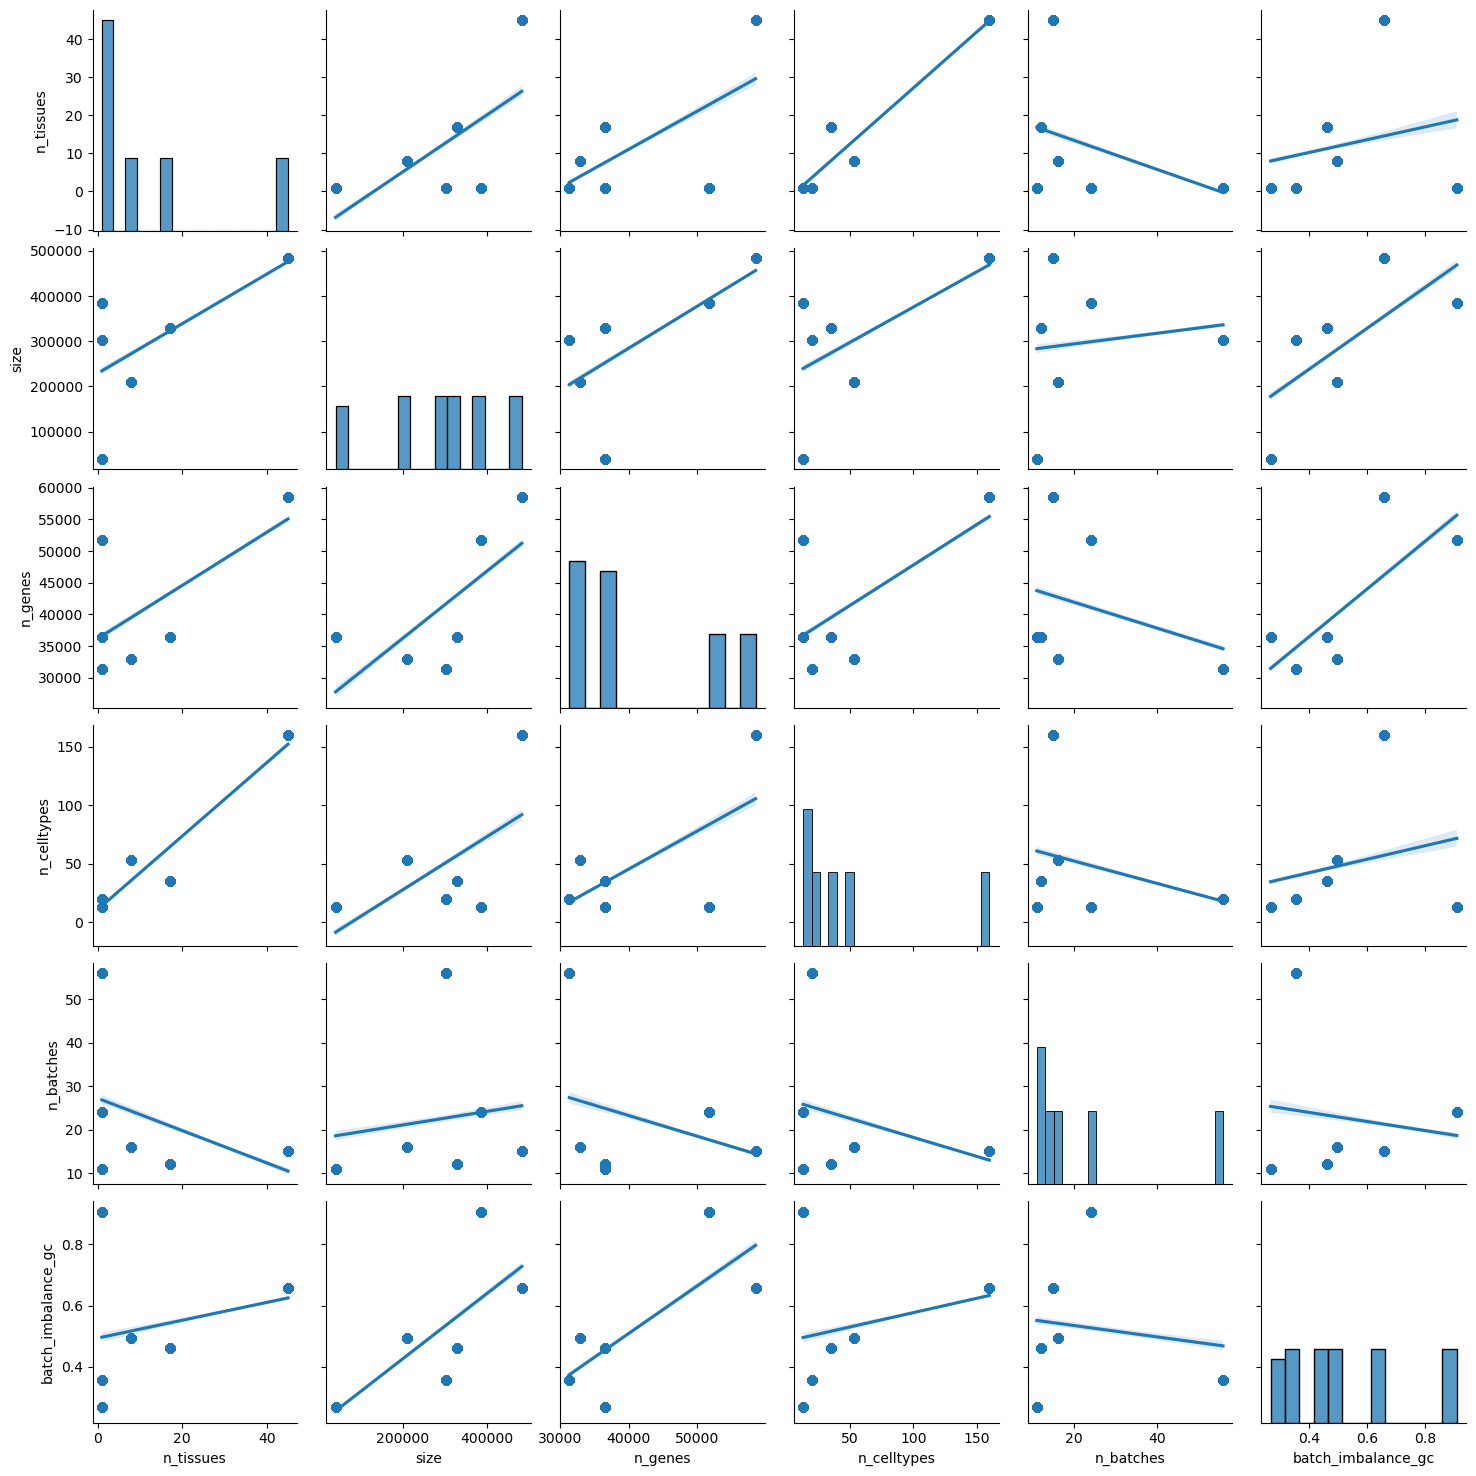

In [24]:
sns.pairplot(df_small, kind="reg")
plt.show()

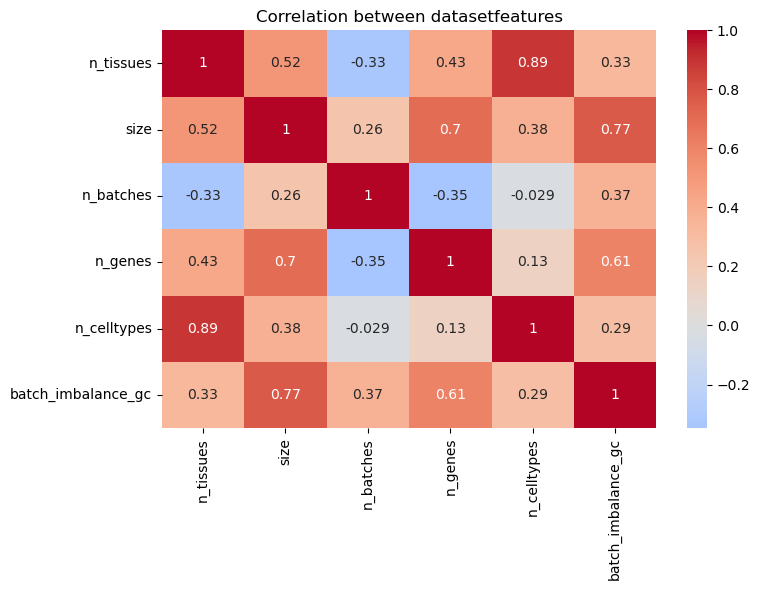

In [25]:
dataset_features = df[
    ["dataset_id","n_tissues", "size", "n_batches", "n_genes", "n_celltypes",
     "batch_imbalance_gc"]
].drop_duplicates("dataset_id")

corr_features = dataset_features.drop(columns="dataset_id").corr(method="spearman")

plt.figure(figsize=(8,6))
sns.heatmap(corr_features, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation between datasetfeatures")
plt.tight_layout()
plt.show()

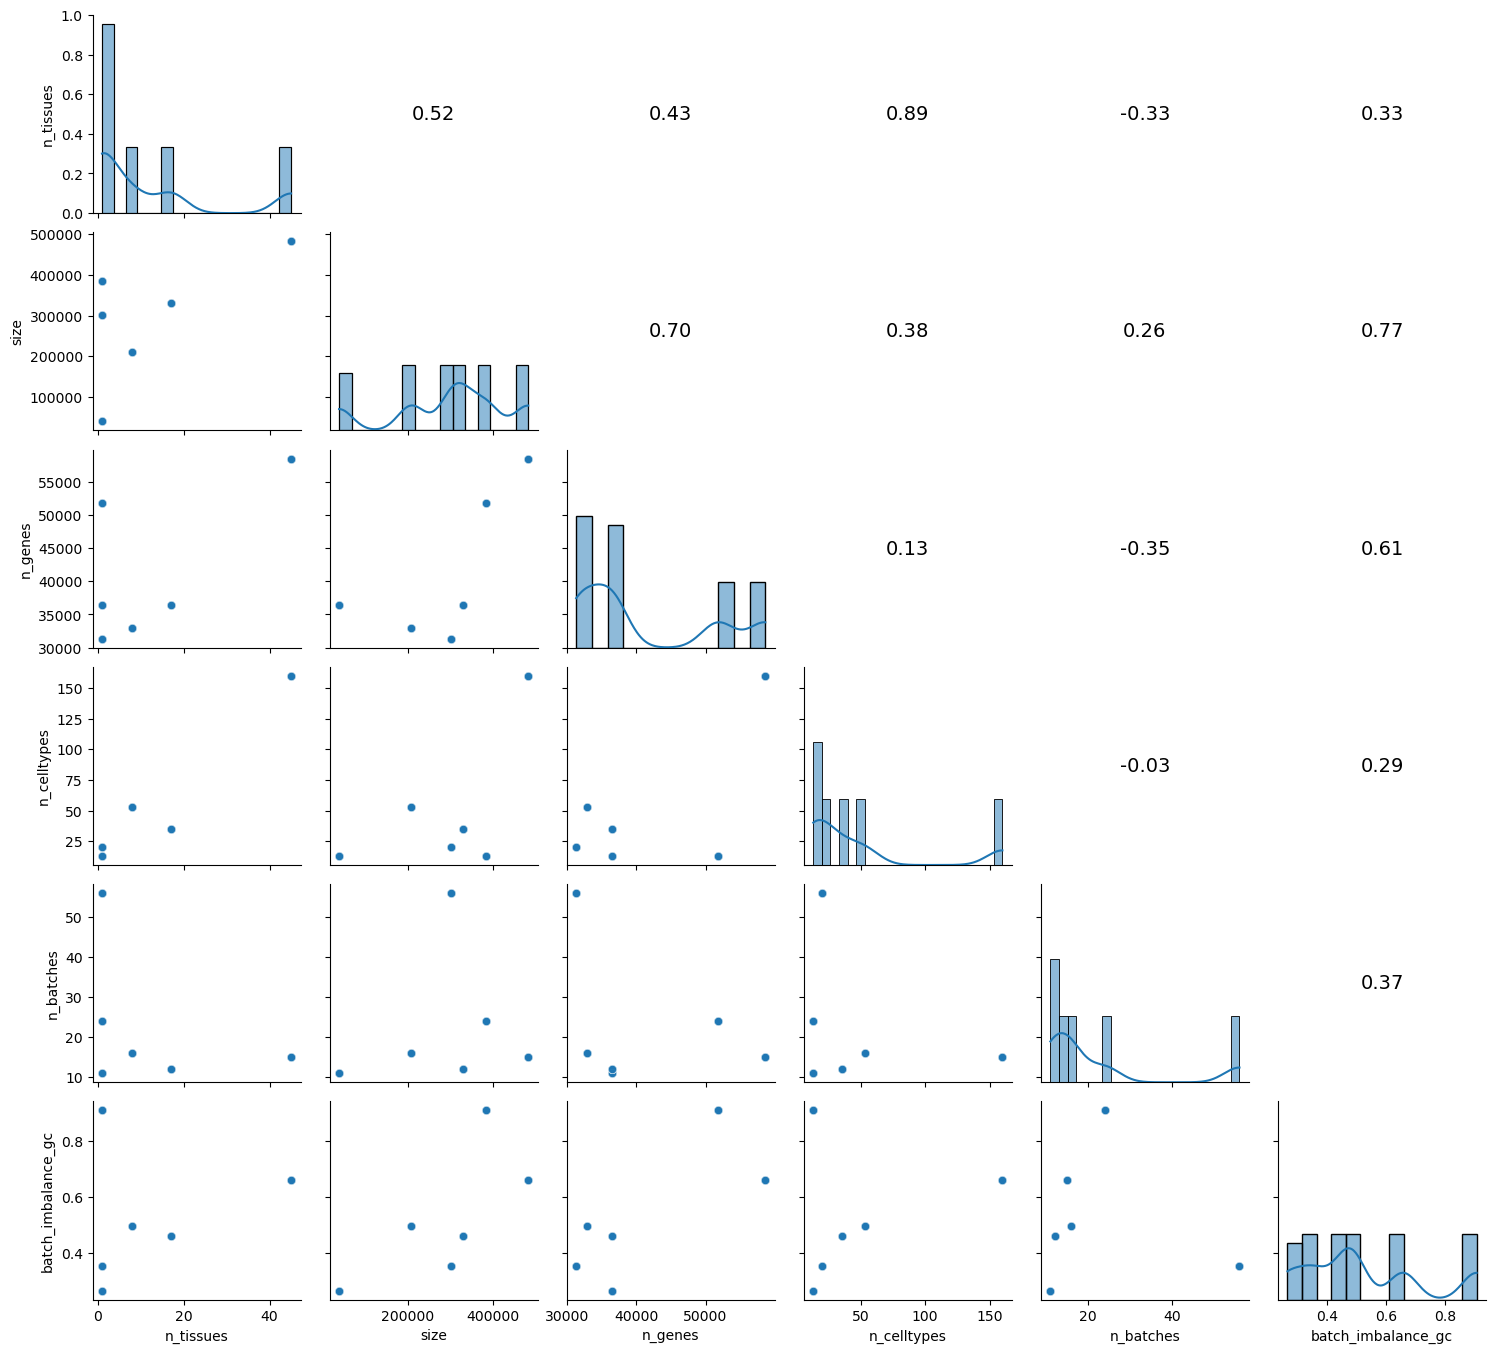

In [28]:
g = sns.PairGrid(df_small)

g.map_lower(sns.scatterplot, alpha=0.5)

def upper_triangle_func(x, y, **kwargs):
    ax = plt.gca()
    corr = corr_features.loc[x.name, y.name]
    ax.annotate(f"{corr:.2f}",
                xy=(0.5, 0.5), xycoords="axes fraction",
                ha="center", va="center", fontsize=14)
    ax.set_axis_off()

g.map_upper(upper_triangle_func)

g.map_diag(sns.histplot, kde=True)

plt.subplots_adjust(top=0.9)
# g.fig.suptitle('Pair Grid with Precomputed Spearman Correlation Values', fontsize=16)
plt.savefig("/Users/seohyon/Downloads/spearman_corr.png", dpi=300, bbox_inches="tight")
plt.show()
